## Logistic Regression 모델

로지스틱 회귀 모델
- 다중공선성 점검 -> 스케일링 -> 베이스라인 -> 교차검증 -> 하이퍼파라미터 튜닝 -> 최종 학습 -> 평가 / 해석

In [64]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import joblib

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, precision_recall_curve, average_precision_score,
)

In [66]:
# 다중공선성(VIF) 점검 및 계수 유의성 검정용
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [67]:
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

**데이터 불러오기**

In [68]:
PROCESSED_DIR = Path(os.environ.get(
    "ANIMAL_SHELTER_DATA_DIR",
    r"C:\Users\SAMSUNG\OneDrive\바탕 화면\전건우\GitHub\Animal-Shelter-Analytics\code",
))
RESULTS_DIR = Path("Model")
RESULTS_DIR.mkdir(exist_ok=True)

In [69]:
X_train = pd.read_csv(os.path.join(PROCESSED_DIR, "X_train.csv"))
X_test = pd.read_csv(os.path.join(PROCESSED_DIR, "X_test.csv"))
y_train = pd.read_csv(os.path.join(PROCESSED_DIR, "y_train.csv")).squeeze("columns")
y_test = pd.read_csv(os.path.join(PROCESSED_DIR, "y_test.csv")).squeeze("columns")

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("\n[클래스 분포 - train]")
print(y_train.value_counts(normalize=True).round(3))
print("\n[클래스 분포 - test]")
print(y_test.value_counts(normalize=True).round(3))
 
print("\n[결측치]")
print("X_train 결측치 총합:", X_train.isna().sum().sum())
print("X_test  결측치 총합:", X_test.isna().sum().sum())

X_train: (98253, 63)  X_test: (24601, 63)

[클래스 분포 - train]
target_adoption
0    0.556
1    0.444
Name: proportion, dtype: float64

[클래스 분포 - test]
target_adoption
0    0.554
1    0.446
Name: proportion, dtype: float64

[결측치]
X_train 결측치 총합: 0
X_test  결측치 총합: 0


**다중공선성 점검 (VIF)**
- 다중공선성(multicollinearity) : 독립변수들끼리 서로 강하게 상관되어 있는 상태
    - 심하면 계수 추정이 불안정해지고 해석이 왜곡됨
- 원-핫 인코딩 시 `drop_first`를 적용하지 않았다면 더미 변수 간 완전한 다중공선성(dummy variable trap)이 발생해 계수 해석이 불안정해질 수 있음. VIF가 비정상적으로 크거나 무한대인 변수가 있는지 확인.

In [70]:
# VIF 계산 (계산량이 많으므로 표본을 일부만 사용해도 무방)
vif_sample = X_train.sample(n=min(5000, len(X_train)), random_state=42).astype(float)
vif_sample = sm.add_constant(vif_sample)
 
vif_df = pd.DataFrame({
    "feature": vif_sample.columns,
    "VIF": [variance_inflation_factor(vif_sample.values, i) for i in range(vif_sample.shape[1])],
})
vif_df = vif_df[vif_df["feature"] != "const"].sort_values("VIF", ascending=False)
 
print("[VIF 상위 15개 - 10 이상이면 다중공선성 의심]")
print(vif_df.head(15).to_string(index=False))
 
if (vif_df["VIF"] > 50).any() or np.isinf(vif_df["VIF"]).any():
    print("\n⚠️  VIF가 매우 크거나 무한대인 변수 존재 -> 원-핫 인코딩 시 drop_first=True 적용 여부 확인 필요")

[VIF 상위 15개 - 10 이상이면 다중공선성 의심]
                             feature        VIF
                   Intake Type_Stray 118.466627
         Intake Type_Owner Surrender  89.342778
           Intake Type_Public Assist  35.945646
breed_grouped_Domestic Shorthair Mix  31.314530
             Intake Condition_Normal  27.758749
                 breed_grouped_Other  25.696218
                Intake Type_Wildlife  23.087885
                            age_days  18.257842
              Animal Type_intake_Dog  15.285828
            Intake Condition_Injured  13.768415
                        age_group_고령  13.296512
               Intake Condition_Sick   9.701795
    breed_grouped_Domestic Shorthair   9.218944
            Intake Condition_Nursing   7.919903
          breed_grouped_Pit Bull Mix   7.737348

⚠️  VIF가 매우 크거나 무한대인 변수 존재 -> 원-핫 인코딩 시 drop_first=True 적용 여부 확인 필요


- VIF가 inf 즉 무한대로 나오는 두 컬럼이 존재
    - 사실상 같은 정보를 중복해서 담고 있다는 뜻
    - 전처리 데이터 수정함
- Intake Type 계열은 같은 범주형 변수에서 나온 더미들
    - 서로 상관되는게 자연스럽지만 118이라는 다소 높은 수가 나옴
    - 원본 인코딩에서 drop_first 적용 여부 확인

**스케일링**
- 연속형 변수만 표준화
- 하드코딩 대신 이진(0/1) 더미가 아닌 컬럼을 자동으로도 탐지해 누락을 방지

In [ ]:
# One-hot encoding된 더미 변수는 그대로 두고, 연속형 변수만 표준화
candidate_cols = ["age_days"]  # 알려진 연속형 변수
auto_numeric_cols = [
    c for c in X_train.columns
    if X_train[c].nunique() > 2 and not set(X_train[c].unique()).issubset({0, 1})
]
numeric_cols = sorted((set(candidate_cols) & set(X_train.columns)) | set(auto_numeric_cols))
print("스케일링 대상 컬럼:", numeric_cols)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

스케일링 대상 컬럼: ['age_days']


- 결과가 원래 알려진거랑 동일하게 나옴 -> 현재 데이터의 연속형 변수는 얘 하나

**베이스라인 모델 학습**
- 최빈 클래스(여기선 not adoption)만 예측하는 DummyClassifier와 비교해 로지스틱 회귀의 실질적 성능 향상폭을 확인

In [72]:
baseline = DummyClassifier(strategy="most_frequent", random_state=42)
baseline.fit(X_train_scaled, y_train)
baseline_pred = baseline.predict(X_test_scaled)
 
print("[베이스라인(최빈 클래스) 성능]")
print(f"Accuracy: {accuracy_score(y_test, baseline_pred):.3f}")
print(f"F1-score: {f1_score(y_test, baseline_pred):.3f}")

[베이스라인(최빈 클래스) 성능]
Accuracy: 0.554
F1-score: 0.000


- accuracy는 클래스 비율과 동일하게 나왔고 입양에 대한 데이터를 예측하지 않아서 F1은 0이 나옴
    - 클래스가 불균형한 데이터에서는 accuracy 뿐만 아니라 이 베이스라인 모델과도 비교해야함

**교차검증**
- 단일 test set 성능만으로는 안정성을 알 수 없으므로 StratifiedKFold(클래스 비율을 각 fold에서 동일하게 유지) 교차검증으로 확인


In [73]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
base_model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
 
for scoring in ["accuracy", "f1", "roc_auc"]:
    scores = cross_val_score(base_model, X_train_scaled, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    print(f"{scoring:>10}: {scores.mean():.3f} ± {scores.std():.3f}")

  accuracy: 0.693 ± 0.001
        f1: 0.689 ± 0.001
   roc_auc: 0.765 ± 0.002


- 표준편차가 매우 작아 fold 간 성능이 안정적임 -> 과적합이 아님을 뜻함
- 이후 test 성능과도 거의 일치 -> 일반화가 잘 된다

**하이퍼파라미터 튜닝**
- 규제 강도 C를 GridSearchCV로 탐색

In [74]:
param_grid = {"C": [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(
    LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
)
grid.fit(X_train_scaled, y_train)
 
print("최적 C:", grid.best_params_["C"])
print(f"최적 CV ROC-AUC: {grid.best_score_:.3f}")

최적 C: 1
최적 CV ROC-AUC: 0.765


규제 강도를 조정해도 이 데이터는 큰 차이가 없다는 결과

**Logistic 모델 학습**
- 클래스 약간의 불균형 존재 -> balanced 로 보정
- c는 gridserach에서 탐색한 최적값 사용

In [75]:
model = LogisticRegression(
    C=grid.best_params_["C"],
    max_iter=2000,
    class_weight="balanced",
    random_state=42,
)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [76]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]
 
print("\n[성능 지표]")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.3f}")
 
print("\n[Classification Report]")
print(classification_report(y_test, y_pred, target_names=["Not Adoption", "Adoption"]))


[성능 지표]
Accuracy : 0.699
Precision: 0.633
Recall   : 0.772
F1-score : 0.696
ROC-AUC  : 0.771

[Classification Report]
              precision    recall  f1-score   support

Not Adoption       0.78      0.64      0.70     13627
    Adoption       0.63      0.77      0.70     10974

    accuracy                           0.70     24601
   macro avg       0.71      0.71      0.70     24601
weighted avg       0.71      0.70      0.70     24601



- recall이 precision보다 높다는 건 모델이 입양될 것이라고 더 적극적으로 예측하는 편이라는 뜻
- non adoption 클래스의 recall은 0.64 -> 실제 입양되지 않은 동물의 36%를 놓치고있음
- 우리는 입양이 어려운 동물을 조기에 찾아내려는 목적이 있기 때문에 이 부분에서 개선이 필요

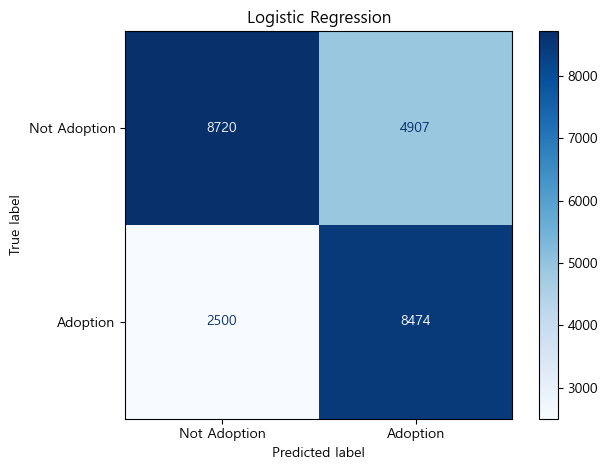

In [77]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Adoption", "Adoption"])
disp.plot(cmap="Blues")
plt.title("Logistic Regression")
plt.tight_layout()
plt.savefig("logreg_confusion_matrix.png", dpi=120)
plt.show()

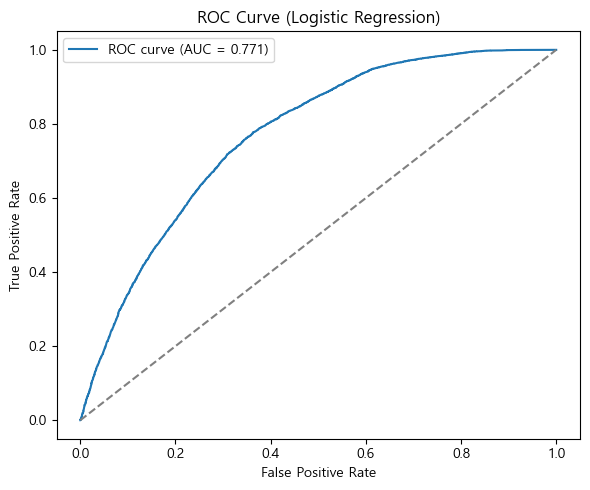

In [78]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc_score(y_test, y_proba):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Logistic Regression)")
plt.legend()
plt.tight_layout()
plt.savefig("logreg_roc_curve.png", dpi=120)
plt.show()

**Precision-Recall 커브 및 최적 임계값**
- 기본 임계값 0.5 대신, 목적(recall 우선 vs precision 우선)에 맞는 임계값을 탐색

F1 최대화 임계값: 0.471 (F1=0.702)

[최적 임계값 적용 시 성능]
Precision: 0.612
Recall   : 0.823
F1-score : 0.702


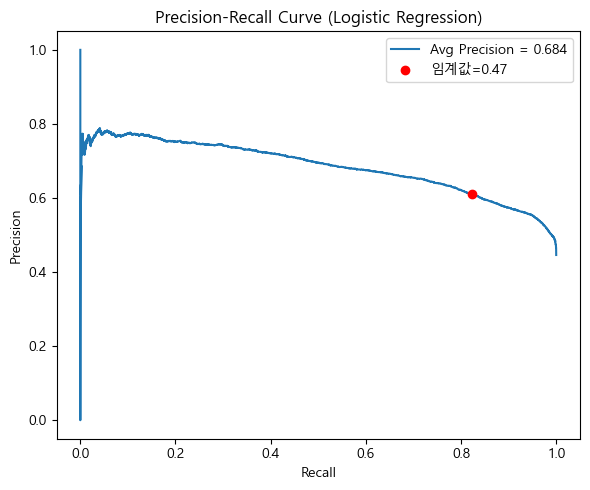

In [79]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores[:-1])  # thresholds는 precisions/recalls보다 길이가 1 짧음
best_threshold = thresholds[best_idx]
 
print(f"F1 최대화 임계값: {best_threshold:.3f} (F1={f1_scores[best_idx]:.3f})")
 
y_pred_opt = (y_proba >= best_threshold).astype(int)
print("\n[최적 임계값 적용 시 성능]")
print(f"Precision: {precision_score(y_test, y_pred_opt):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred_opt):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred_opt):.3f}")
 
plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions, label=f"Avg Precision = {average_precision_score(y_test, y_proba):.3f}")
plt.scatter(recalls[best_idx], precisions[best_idx], color="red", zorder=5, label=f"임계값={best_threshold:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Logistic Regression)")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "logreg_pr_curve.png", dpi=120)
plt.show()

- 빨간점이 F1을 최대화하는 임계값
    - 적용시 recall이 크게 오르는 대신 precision이 떨어짐
- 목적에 맞춰 임계값 설정하는게 바람직함

**모델 보정 확인**
- 예측 확률이 실제 관측 빈도와 얼마나 일치하는지 확인

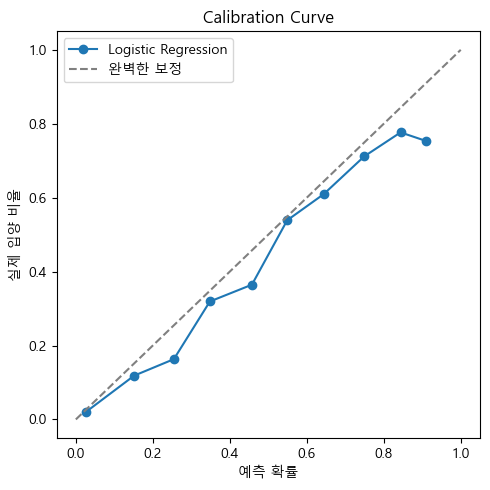

In [80]:
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
 
plt.figure(figsize=(5, 5))
plt.plot(prob_pred, prob_true, marker="o", label="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="완벽한 보정")
plt.xlabel("예측 확률")
plt.ylabel("실제 입양 비율")
plt.title("Calibration Curve")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "logreg_calibration_curve.png", dpi=120)
plt.show()

**계수 해석**
- 표준화된 변수 기준 계수(coefficient)와 오즈비(odds ratio = e^계수)로 각 변수가 입양 확률에 미치는 영향을 해석


[영향력 상위 15개 변수 - 계수/오즈비]
                             feature  coefficient  odds_ratio
                  sex_status_unknown    -3.156017    0.042595
                Intake Type_Wildlife    -2.564345    0.076970
           Intake Type_Public Assist    -1.654479    0.191192
      Intake Type_Euthanasia Request    -1.624850    0.196941
                            has_name     1.141808    3.132426
                   breed_grouped_Bat    -1.104199    0.331476
               breed_grouped_Bat Mix    -1.008805    0.364654
                        age_group_성체    -0.797728    0.450351
breed_grouped_Domestic Shorthair Mix    -0.741558    0.476371
                       age_group_청년기    -0.729909    0.481953
               Intake Condition_Sick    -0.652803    0.520584
          breed_grouped_Pit Bull Mix    -0.645499    0.524401
         Intake Type_Owner Surrender     0.633204    1.883636
    breed_grouped_Domestic Shorthair    -0.608075    0.544398
           breed_grouped_Siamese Mix    -0.6

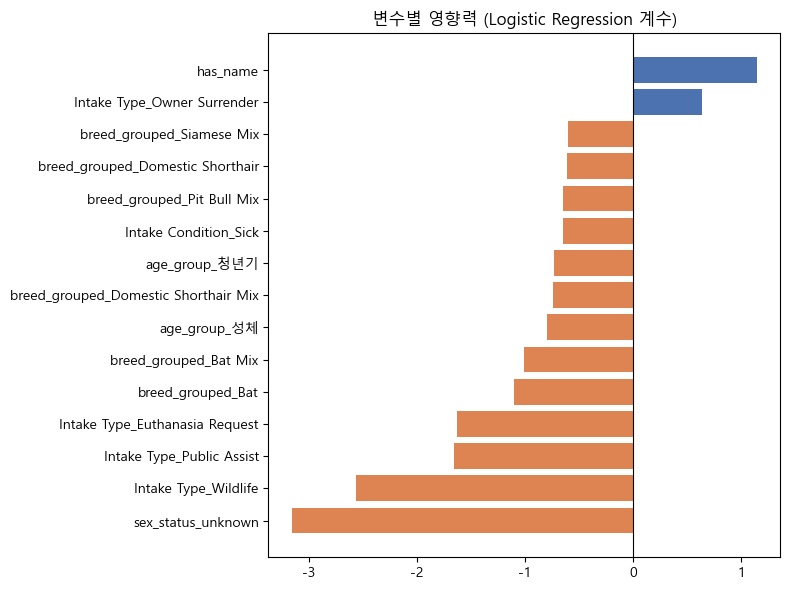

In [81]:
coef_df = pd.DataFrame({
    "feature": X_train_scaled.columns,
    "coefficient": model.coef_[0],
})
coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])
coef_df = coef_df.reindex(coef_df["coefficient"].abs().sort_values(ascending=False).index)
 
print("\n[영향력 상위 15개 변수 - 계수/오즈비]")
print(coef_df.head(15).to_string(index=False))
 
plt.figure(figsize=(8, 6))
top15 = coef_df.head(15).sort_values("coefficient")
colors = ["#DD8452" if c < 0 else "#4C72B0" for c in top15["coefficient"]]
plt.barh(top15["feature"], top15["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("변수별 영향력 (Logistic Regression 계수)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "logreg_coefficients.png", dpi=120)
plt.show()

**실행 결과 주요 변수**
- `has_name`(이름 유무): 계수 +1.14, 오즈비 3.13 -> 이름이 있는 동물은 없는 동물보다 입양 오즈가 약 3.1배 높음. 가장 긍정적인 영향을 주는 변수.
- `Intake Type_Wildlife`: 계수 -2.66, 오즈비 0.07 -> 야생동물로 입소한 경우 입양 오즈가 약 93% 낮음(가장 부정적인 영향). `Intake Type_Public Assist`, `Intake Type_Euthanasia Request`도 강한 음의 영향.
- `sex_Unknown` / `sterilized_status_Unknown`은 계수가 완전히 동일(-1.59) -> 앞선 VIF 점검에서 확인한 다중공선성이 계수에 그대로 반영된 것이므로, 두 변수의 효과를 독립적으로 해석하면 안 되고 '정보 미상' 하나의 효과로 묶어 보는 것이 정확함.
- 품종(`breed_grouped_*`) 대부분이 음의 계수 -> 특정 품종 그룹에 속하는 것 자체가(기준 품종 대비) 입양 확률을 낮추는 방향으로 나타남.

**통계적 유의성 검정**

In [82]:
try:
    X_sm = sm.add_constant(X_train_scaled.astype(float))
    logit_sm = sm.Logit(y_train.astype(float), X_sm)
    result_sm = logit_sm.fit(disp=0, maxiter=200)
 
    pvalues = result_sm.pvalues.drop("const").sort_values()
    print("[p-value 상위(유의미) 15개 변수]")
    print(pvalues.head(15).to_string())
 
    n_insig = (result_sm.pvalues.drop("const") > 0.05).sum()
    print(f"\n유의수준 0.05 기준 유의하지 않은 변수 개수: {n_insig} / {len(pvalues)}")
except Exception as e:
    print("statsmodels 적합 실패 (다중공선성 등의 이슈일 수 있음):", e)

[p-value 상위(유의미) 15개 변수]
has_name                                   0.000000e+00
sex_status_unknown                        8.141685e-243
age_group_청년기                             8.288047e-198
age_group_청소년기                             1.334393e-75
sterilized_status_Sterilized               6.559186e-68
age_group_성체                               1.069340e-60
Intake Type_Public Assist                  1.335199e-34
age_days                                   5.437195e-26
breed_grouped_Pit Bull Mix                 4.503045e-21
breed_grouped_Domestic Shorthair Mix       1.724967e-18
intake_season_한겨울                          1.204363e-12
breed_grouped_Domestic Shorthair           1.130873e-11
breed_grouped_Domestic Medium Hair Mix     9.284195e-10
sex_Male                                   1.696911e-09
Intake Type_Euthanasia Request             2.972541e-09

유의수준 0.05 기준 유의하지 않은 변수 개수: 15 / 63


In [83]:
metrics_record = {
    "model": "LogisticRegression",
    "best_C": grid.best_params_["C"],
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
    "avg_precision": average_precision_score(y_test, y_proba),
    "optimal_threshold": best_threshold,
}
 
metrics_path = RESULTS_DIR / "model_comparison.csv"
metrics_df = pd.DataFrame([metrics_record])
if metrics_path.exists():
    existing = pd.read_csv(metrics_path)
    existing = existing[existing["model"] != "LogisticRegression"]
    metrics_df = pd.concat([existing, metrics_df], ignore_index=True)
metrics_df.to_csv(metrics_path, index=False)
print(f"성능 지표 저장 완료: {metrics_path}")
 
 
model_path = RESULTS_DIR / "logreg_model.pkl"
joblib.dump(
    {"model": model, "scaler": scaler, "numeric_cols": numeric_cols, "threshold": best_threshold},
    model_path,
)
print(f"\n모델 저장 완료: {model_path}")
 

성능 지표 저장 완료: Model\model_comparison.csv

모델 저장 완료: Model\logreg_model.pkl
